# A1: Data Acquisition

In [70]:
import numpy as np
import pandas as pd
import json
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as path_effects

In [2]:
with open("business-licences.geojson", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.json_normalize([feature["properties"] for feature in data["features"]])

df["geometry"] = [feature["geometry"] for feature in data["features"]]

In [3]:
# shape
print("Shape:", df.shape)

Shape: (204108, 28)


In [4]:
# data types
print(df.dtypes)

folderyear                   str
licencersn                   str
licencenumber                str
licencerevisionnumber        str
businessname                 str
businesstradename            str
status                       str
issueddate                   str
expireddate                  str
businesstype                 str
businesssubtype              str
unit                         str
unittype                     str
house                        str
street                       str
city                         str
province                     str
country                      str
postalcode                   str
localarea                    str
numberofemployees        float64
feepaid                  float64
extractdate                  str
geom                     float64
geo_point_2d             float64
geo_point_2d.lon         float64
geo_point_2d.lat         float64
geometry                  object
dtype: object


In [5]:
# missing value count
print ("Missing Value Count")
print((df.isna()).sum().sort_values(ascending=False))


# missing value percentage
print ("\nMissing Value Percentage")
print((df.isna().mean() * 100).sort_values(ascending=False))

Missing Value Count
geo_point_2d             204108
geom                     204108
businesssubtype          182590
unittype                 155458
unit                     155194
businesstradename        126801
geometry                 101542
geo_point_2d.lat         101542
geo_point_2d.lon         101542
postalcode                95142
house                     94404
street                    94387
feepaid                   75455
country                   44875
issueddate                28808
expireddate               28784
businessname              13473
localarea                  2714
province                     80
city                         56
businesstype                  0
licencersn                    0
numberofemployees             0
extractdate                   0
status                        0
licencerevisionnumber         0
licencenumber                 0
folderyear                    0
dtype: int64

Missing Value Percentage
geo_point_2d             100.000000
geom     

In [6]:
# status counts
print(df["status"].value_counts())

status
Issued                  167012
Pending                  14949
Gone Out of Business     10411
Inactive                  6563
Cancelled                 5173
Name: count, dtype: int64


In [7]:
# number of business types
print(df["businesstype"].nunique())

94


In [8]:
# top 20 business types
print(df["businesstype"].value_counts().head(20))

businesstype
Long-term Rental                          45410
Health Care Professionals and Services    18740
General Contractor                        15890
Short-term Rental Operator                13411
Retail Dealer                              9446
Consulting and Management Services         7235
Trade Contractor                           6660
Legal Services                             6416
Restaurant                                 6204
Beauty Services                            5421
Business Support Services                  5103
Limited Service Food Establishment         4806
Financial Services                         3692
Information Communication Technology       3587
Real Estate Services                       3342
Retail Dealer - Food                       2590
Wholesale Dealer - Non-Food                2542
Association or Society                     2292
Building Repair and Maintenance            2253
Architectural and Engineering Services     2100
Name: count, dtype: int64


In [9]:
df.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geo_point_2d.lon,geo_point_2d.lat,geometry
0,24,4518841,24-138560,10,Nobl Collective Ltd,NaN,Issued,2023-12-28T13:34:28-08:00,2024-12-31,Consulting and Management Services,...,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN,None
1,24,4518843,24-138562,10,645064 BC Ltd,Trade Exchange Canada,Issued,2023-11-20T13:40:18-08:00,2024-12-31,Business Support Services,...,NaN,Kitsilano,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN,None
2,24,4518844,24-138563,10,(Louise Turgeon),Turgeon Business Consulting,Issued,2023-11-21T14:30:07-08:00,2024-12-31,Consulting and Management Services,...,NaN,Downtown,1.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,NaN,NaN,None
3,24,4518848,24-138567,10,Baron Global Financial Canada Ltd,NaN,Issued,2023-12-11T10:12:12-08:00,2024-12-31,Consulting and Management Services,...,V6E 2E9,Downtown,5.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,-123.118193,49.287734,"{'coordinates': [-123.118192793095, 49.2877342..."
4,24,4518856,24-138576,10,Jennifer D S Dezell (Jennifer Dezell),Dentons Canada LLP,Issued,2023-12-08T16:34:17-08:00,2024-12-31,Legal Services,...,V6C 3R8,Downtown,217.0,NaN,2026-07-01T02:32:17-07:00,NaN,NaN,-123.113252,49.286653,"{'coordinates': [-123.113252488858, 49.2866526..."


# A1: Data Cleaning

## Remove Businesses with Missing Geographic Values

In [10]:
df = df[df["geometry"].notna()].copy()

##### Given that approximately 49.75% of the geometric locations are missing, it would not be possible to map these businesses and include them in the location-based clustering that is part of A2. Therefore, it seems unnecessary to retain these records, and I removed them.

## Remove Unactive Businesses

In [11]:
df = df[df["status"] == "Issued"].copy()

print(df["status"].value_counts())

status
Issued    85874
Name: count, dtype: int64


##### The only businesses I decided to retain were those with an Issued license. I removed businesses with a Pending, Cancelled, Inactive, or Gone out of Business status because they are not currently operating and likely would unnecessarily distort the clustering.

## Handling NumberofEmployees Field

In [12]:
print(df["numberofemployees"].isna().sum())

print(df["numberofemployees"].isna().mean() * 100)

0
0.0


##### Since there are no missing numberofemployees values, I did not need to clean anything.

## Handling FeePaid Field

In [13]:
print(df["feepaid"].isna().sum())

print(df["feepaid"].isna().mean() * 100)

26480
30.835875818059016


In [23]:
df = df[df["feepaid"].notna()].copy()

##### I decided to get rid of these missing values even though I lose almost a third of my data. This is because I am planning on utilizing them as a clustering feature for A3, therefore, these missing values will be an obstacle in the future. Additionally, I did not impute them with the mean value of the field because replacing the missing values with artificial values would likely alter the results when I actually cluster them. This is because it would be used to group similar businesses together and would distort the result, possibly making unsimilar businesses seem more similar than they actually are.

## Narrow Business Types

In [24]:
print(df["businesstype"].nunique())

88


In [30]:
print(df["businesstype"].value_counts().head(15))

businesstype
Health Care Professionals and Services    8599
Long-term Rental                          6761
Retail Dealer                             3951
Legal Services                            3483
Restaurant                                3348
Beauty Services                           2770
Limited Service Food Establishment        2648
Business Support Services                 1938
Consulting and Management Services        1633
Financial Services                        1627
Real Estate Services                      1372
Retail Dealer - Food                      1321
General Contractor                        1233
Information Communication Technology      1178
Association or Society                    1147
Name: count, dtype: int64


In [26]:
top15 = df["businesstype"].value_counts().nlargest(15).index

print(top15)

Index(['Health Care Professionals and Services', 'Long-term Rental',
       'Retail Dealer', 'Legal Services', 'Restaurant', 'Beauty Services',
       'Limited Service Food Establishment', 'Business Support Services',
       'Consulting and Management Services', 'Financial Services',
       'Real Estate Services', 'Retail Dealer - Food', 'General Contractor',
       'Information Communication Technology', 'Association or Society'],
      dtype='str', name='businesstype')


In [27]:
df["businesstype_clean"] = df["businesstype"].where(
    df["businesstype"].isin(top15),
    "Other"
)

In [28]:
df["businesstype_clean"].value_counts()

businesstype_clean
Other                                     16257
Health Care Professionals and Services     8599
Long-term Rental                           6761
Retail Dealer                              3951
Legal Services                             3483
Restaurant                                 3348
Beauty Services                            2770
Limited Service Food Establishment         2648
Business Support Services                  1938
Consulting and Management Services         1633
Financial Services                         1627
Real Estate Services                       1372
Retail Dealer - Food                       1321
General Contractor                         1233
Information Communication Technology       1178
Association or Society                     1147
Name: count, dtype: int64

##### After cleaning up the data there were 89 business types remaining. I decided to keep the top 15, and group the rest under "other." This decision was based on the value count of each business type. The top 15 business types were all businesses who had a count of above 1100. All of the remaining business types had a count of below 1500, hence it seemed like a reasonable decision to group them under "other" since their count wasn't significant.

## Manageable Dataset Size

In [31]:
print("Shape:", df.shape)

Shape: (59266, 29)


In [32]:
df = df[df["issueddate"].notna()].copy()

In [33]:
df = df[df["expireddate"].notna()].copy()

##### Given that after all of the cleaning I still had 59266 records, I made the decision to remove records where issueddate or expireddate was a missing value. Although, I currently am not meant to use this field to cluster for A2, this now makes it a viable option for A3 while also helping make the dataset size more manageable if I need it in the future. I did not impute this value because I did not want to risk distorting the result and making unsimilar businesses seem more similar than they actually are when I do eventually use it as a feature to cluster for A3.

In [34]:
print("Shape:", df.shape)

Shape: (59266, 29)


##### I now have 59266 records in the dataset. I believe a dataset of 20000 records would be ideal because it would reduce the amount of computation needed while also ensuring a decent volume when it comes to plotting. It is a good balance.

In [35]:
df = df.sample(n=20000, random_state=42)
print("Shape:", df.shape)

Shape: (20000, 29)


##### There are now 20000 records in the dataset that were selected randomly. This would reduce the computation load while also maintaining an adequate representation of business types and locations.

In [36]:
df["businesstype_clean"].value_counts()

businesstype_clean
Other                                     5580
Health Care Professionals and Services    2895
Long-term Rental                          2230
Retail Dealer                             1339
Legal Services                            1189
Restaurant                                1128
Beauty Services                            931
Limited Service Food Establishment         890
Business Support Services                  621
Financial Services                         553
Consulting and Management Services         546
Real Estate Services                       466
Retail Dealer - Food                       438
General Contractor                         419
Association or Society                     392
Information Communication Technology       383
Name: count, dtype: int64

In [38]:
df["businesstype"].value_counts().head(20)

businesstype
Health Care Professionals and Services           2895
Long-term Rental                                 2230
Retail Dealer                                    1339
Legal Services                                   1189
Restaurant                                       1128
Beauty Services                                   931
Limited Service Food Establishment                890
Business Support Services                         621
Financial Services                                553
Consulting and Management Services                546
Real Estate Services                              466
Retail Dealer - Food                              438
General Contractor                                419
Association or Society                            392
Information Communication Technology              383
Wholesale Dealer - Non-Food                       359
Parking Area / Garage                             279
Health Care Facility                              265
Architectural a

##### To ensure the quantity of business types weren't distorted and misrepresented, I counted them again. This seems to be a fair representation as the top 15 business types are the same and their counts are still above other business types.

## Check for Outliers

### Number of Employees

In [39]:
df["numberofemployees"].describe()

count    20000.000000
mean        18.737450
std        101.750844
min          0.000000
25%          1.000000
50%          3.000000
75%          9.000000
max       4000.000000
Name: numberofemployees, dtype: float64

##### Although 4000 as a max would raise concern about outliers considering the various percentiles, it is also important to remember that among these businesses there are also large employers that do legitimately hire thousands of employees. On the other hand, it is also reasonable that some businesses have no employees as they may simply be startups. Overall, there seems to be no concern for outliers with the number of employees field.

#### Fees Paid

In [40]:
df["feepaid"].describe()

count    20000.000000
mean       660.178721
std       1569.980894
min          2.000000
25%        265.000000
50%        277.000000
75%        476.250000
max      63722.000000
Name: feepaid, dtype: float64

##### The maximum being $63722.00 is concerning, hence I am going to investigate. Additionally, since the mean is larger than the median, the data is skewed to the right. However, this would be expected since majority of businesses are smaller and hence pay a smaller fees. On the other hand, larger companies, which there are fewer of, have to pay more fees.

In [41]:
df.nlargest(10, "feepaid")[["businessname", "businesstype", "feepaid"]]

,businessname,businesstype,feepaid
52722,Langara Gardens Holdings Ltd,Long-term Rental,63722.0
40604,Langara Gardens Holdings Ltd,Long-term Rental,61110.0
117367,Westsea Construction Ltd,Long-term Rental,27048.0
116275,SCG Aquarius Vancouver Hotel Inc,Hotel or Motel,26613.0
40442,Feliz Enterprises Ltd,Long-term Rental,26064.0
116262,Rosedale On Robson Suite Hotel Inc,Hotel or Motel,26013.0
11530,0888189 BC Ltd,Long-term Rental,25662.0
62984,OCEAN PACIFIC HOTELS LTD,Hotel or Motel,25273.0
39443,Rosedale On Robson Suite Hotel Inc,Hotel or Motel,24948.0
146759,Hotel Vancouver (GP) Inc,Hotel or Motel,24528.0


##### The companies with the most fees are bigger companies, hence, there do not seem to be any outliers or any information that seems mismatched. Therefore, I am not going to remove any outliers in this field.

# A2: Location-Only Clustering

In [42]:
df.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geo_point_2d.lon,geo_point_2d.lat,geometry,businesstype_clean
23009,25,4887309,25-303724,00,COMFORT DIRECT SUPPLY LTD.,NaN,Issued,2025-12-03T15:40:47-08:00,2025-12-31,Trade Contractor,...,Renfrew-Collingwood,2.0,134.0,2026-07-01T02:32:24-07:00,NaN,NaN,-123.024196,49.232667,"{'coordinates': [-123.02419552672, 49.23266703...",Other
85247,25,4620365,25-112644,00,(Bradley Yee),Dr. Bradley Yee FCCSS(C),Issued,2024-11-18T14:30:50-08:00,2025-12-31,Health Care Professionals and Services,...,Kensington-Cedar Cottage,1.0,265.0,2026-07-01T02:32:19-07:00,NaN,NaN,-123.069471,49.260742,"{'coordinates': [-123.069470930894, 49.2607423...",Health Care Professionals and Services
12914,25,4650844,25-143121,00,Craig A Ash Law Corporation,NaN,Issued,2024-11-21T16:44:42-08:00,2025-12-31,Legal Services,...,Downtown,46.0,265.0,2026-07-01T02:32:21-07:00,NaN,NaN,-123.111518,49.285575,"{'coordinates': [-123.111518282345, 49.2855753...",Legal Services
138746,25,4770604,25-246250,00,Turntable Hospitality Corporation,Mt Pleasant Vintage & Provisions,Issued,2025-07-07T11:12:56-07:00,2025-07-27,Temp Liquor Licence Amendment,...,Mount Pleasant,50.0,123.0,2026-07-01T02:32:23-07:00,NaN,NaN,-123.105830,49.265855,"{'coordinates': [-123.105830062359, 49.2658551...",Other
157174,25,4630118,25-122397,00,1199248 BC Ltd,NaN,Issued,2024-12-06T15:16:24-08:00,2025-12-31,Long-term Rental,...,Grandview-Woodland,0.0,1880.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.057934,49.289061,"{'coordinates': [-123.05793394507, 49.28906108...",Long-term Rental


##### I did this to recheck the name of the variables describing longitude and latitude.

In [43]:
location_df = df[["geo_point_2d.lat", "geo_point_2d.lon"]].copy()

##### Created a seperate df with just locations because this is what I am using for clustering.

In [44]:
scaler = StandardScaler()
location_df_scaled = scaler.fit_transform(location_df)

##### It is important to scale the location longitude and latitude values because it ensures they all have equal weight and importance and it also prevents skewing when being clustered.

## K-Means

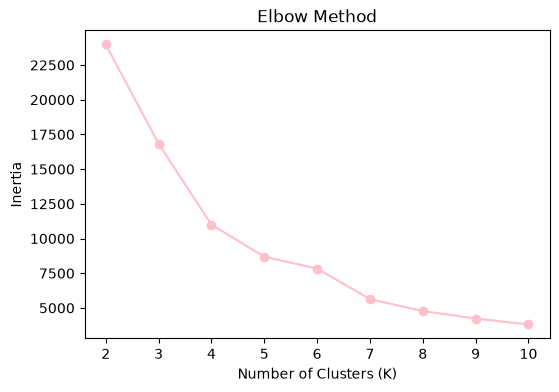

In [45]:
##BEGIN[ChatGPT][https://chatgpt.com/]"I am meant to create clustering using K-means. I am meant to use the elbow method to choose K and then fit, how would I go about this?"

inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(location_df_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o', color='pink')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

##END[ChatGPT]

plt.show()

##### With the elbow method we are meant to choose a K value where inertia begins to decrease at a slower rate and flatten (aka a point that looks like an elbow). Before K=6 there were significant decreases in intertia, meaning that each cluster hada  big impact on inertia and improved the model fit. After K=6, there were smaller reductions in inertia meaning that adding more clusters didn't have much impact on inertia. Additionally, K=6 also resembles an elbow joint. Hence, I am choosing 6 as my K value

In [46]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

##BEGIN[ChatGPT][https://chatgpt.com/]"What sklearn.cluster function do I use to fit a dataset for k means again?"

df["kmeans_cluster"] = kmeans.fit_predict(location_df_scaled)

##END[ChatGPT]

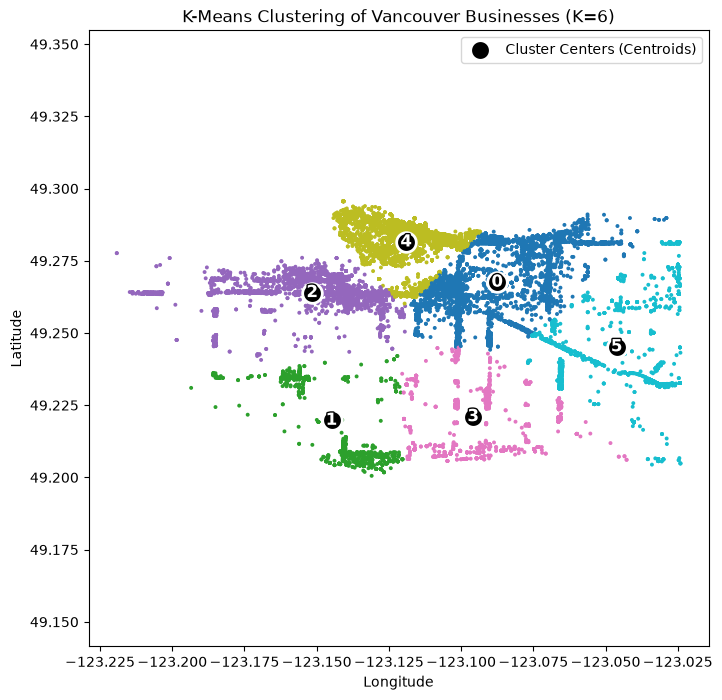

<Figure size 640x480 with 0 Axes>

In [47]:
##BEGIN[ChatGPT][https://chatgpt.com/]"This is my current plotting code for k means clustering, how would you make it look better" (fed it my then plotting code)


plt.figure(figsize=(8, 8))

scatter = plt.scatter(
    df["geo_point_2d.lon"],
    df["geo_point_2d.lat"],
    c=df["kmeans_cluster"], 
    cmap="tab10",
    s=8,
    edgecolor='none'       
)


scaled_centroids = kmeans.cluster_centers_
actual_centroids = scaler.inverse_transform(scaled_centroids)


plt.scatter(
    actual_centroids[:, 1],   
    actual_centroids[:, 0],  
    color='black',
    marker='o',
    s=200,
    edgecolor='white',
    linewidth=2,
    label='Cluster Centers (Centroids)'
)

for i, (lat, lon) in enumerate(actual_centroids):
    txt = plt.text(
        lon, 
        lat, 
        str(i), 
        color='white', 
        fontweight='bold',
        fontsize=12,
        va='center', 
        ha='center',
        zorder=6 
    )
    txt.set_path_effects([path_effects.withStroke(linewidth=2, foreground='black')])


num_k = df["kmeans_cluster"].nunique()
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"K-Means Clustering of Vancouver Businesses (K={num_k})")
plt.axis("equal")
plt.legend()
plt.show()


##END[ChatGPT]

plt.tight_layout()
plt.show()

In [48]:
print(df["kmeans_cluster"].value_counts())

kmeans_cluster
4    8467
0    4312
2    3352
5    1518
3    1219
1    1132
Name: count, dtype: int64


### How do the K-means clusters map onto actual Vancouver geography — do they correspond to anything you'd recognize (downtown core, west side, etc.)?

##### The K-Means clusters map does actually seem to correspond to actual Vancouver geography. Personally, I recognize that the green cluster seems to correspond to downtown Vancouver, specifically the Gastown and Yaletown areas. Additionally, I also recognize that the cyan cluster West Vancouver such as Kitsilano and possibly Granville. Given these two areas I recognize, I can assume that the olive cluster is Central Vancouver, purple cluster is South Vancouver, and blue cluster is Southeast Vancouver. This would then mean that the pink cluster is East Vancouver, likely including Commercial Drive and East Hastings St.

## DBSCAN

In [49]:
dbscan = DBSCAN(
    eps=0.03,
    min_samples=10
)

df["dbscan_cluster"] = dbscan.fit_predict(location_df_scaled)

##### I experimented with the eps and min_samples value numerous times to see what would give me the best outcome. I started at eps = 0.12 and worked my way down to 0.03. I found that eps 0.03 was better because it seemed to strike the best balance between recognizing high-density business areas and more spread out businesses which it treated like noise. This was because an eps of 0.03 is equivalent to approximately 3.3km given that the dataset being used was measured in degrees.

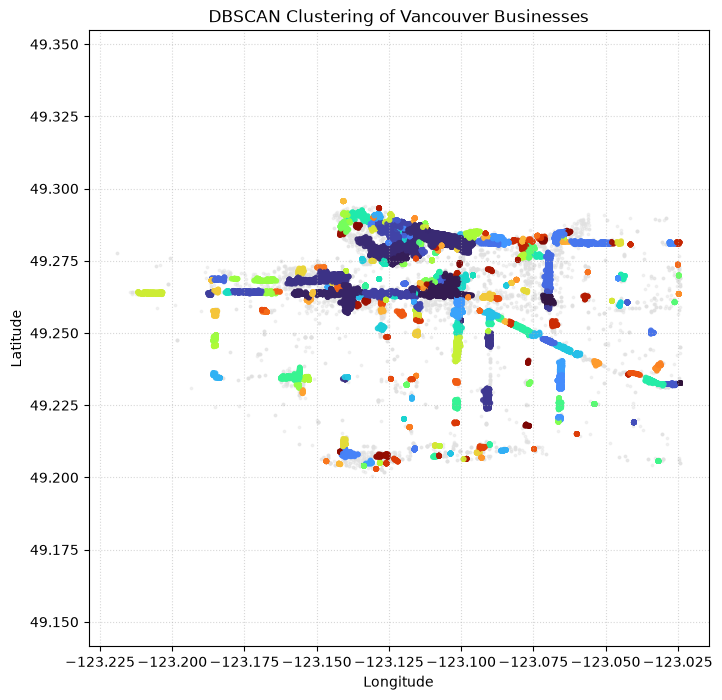

In [50]:
##BEGIN[ChatGPT][https://chatgpt.com/]"This is my current plotting code for DBSCAN, how would you make it look better" (fed it my then plotting code)

plt.figure(figsize=(8, 8))

noise = df[df['dbscan_cluster'] == -1]
clustered = df[df['dbscan_cluster'] != -1]

plt.scatter(
    noise["geo_point_2d.lon"],
    noise["geo_point_2d.lat"],
    c="#E0E0E0",
    s=3,
    alpha=0.4,
    label="Noise"
)

scatter = plt.scatter(
    clustered["geo_point_2d.lon"],
    clustered["geo_point_2d.lat"],
    c=clustered["dbscan_cluster"],
    cmap="turbo",
    s=10,
    alpha=0.9
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Vancouver Businesses")

plt.axis("equal") 
plt.grid(True, linestyle=":", alpha=0.5)

##END[ChatGPT]

plt.show()

In [51]:
print(df["dbscan_cluster"].value_counts())

dbscan_cluster
 8      3810
-1      3078
 17     1237
 16      887
 3       685
        ... 
 242      10
 233      10
 240       8
 235       8
 234       6
Name: count, Length: 248, dtype: int64


##### Although there being 3078 points classified as -1 or noise may typically be concerning, I beilieve that this is somewhat reasonable for this dataset considering it consists of 20000 businesses. I do not want to increase the eps anymore because 3.3 km seems like a reasonable eps, and increasing it more will just cause overpopulated clusters.

### How do the DBSCAN clusters compare? Where do the two methods agree or disagree, and why — think about what each algorithm assumes about cluster shape and density, and what DBSCAN's "noise" points represent.

#### Agreements

##### Both of the DBSCAN and K-Means clusters agree on the downtown Vancouver area as being a dense business hub. This is shown through the big cluster at the top of the DBSCAN plot and green cluster at the top of the K-Means plot. Additionally, they both seem to follow the same map of Vancouver. This is recognizeable as they both have the same distinct shape such as that diagonal line in the bottom left. However, this makes sense as they were both fed the same latitude and longitude coordinates.

#### Disagreements

##### Where they differ is that K-means breaks down Vancouver into 6 clusters, meaning it generalizes an area and forces every point into a cluster and region of Vancouver. On the other hand, DBSCAN breaks down Vancouver much more. To be more specific, it broke down Vancouver into 248 clusters, meaning it isolated a lot of areas. It then also identified businesses that did not seemingly fit into any smaller area and classified them as noise.

#### Assumptions

##### K-means assumes that all clusters are approximately the same size, hence, it tries breaking up the businesses into 6 (k value) equally-sized clusters. It lumps low-density business areas into high-density business-areas because it cannot handle a variation in density.

##### DBSCAN does not assume anything about the shape. It does not have a set amount of clusters it is trying to break the dataset into. Instead it uses its eps value and min_samples value to break down the area into clusters, with each cluster being within the 0.03 eps (eps value) of each other and each cluster having a minimum of 10 businesses (min_samples). The points that do not become a part of a core point due to not being within range of other clusters and not being within range of a minimum of 9 other businesses to create their own core point. Due to this, they are then classified as noise and counted under the -1 group.

# A3: Feature-Based Clustering

In [52]:
df.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,feepaid,extractdate,geom,geo_point_2d,geo_point_2d.lon,geo_point_2d.lat,geometry,businesstype_clean,kmeans_cluster,dbscan_cluster
23009,25,4887309,25-303724,00,COMFORT DIRECT SUPPLY LTD.,NaN,Issued,2025-12-03T15:40:47-08:00,2025-12-31,Trade Contractor,...,134.0,2026-07-01T02:32:24-07:00,NaN,NaN,-123.024196,49.232667,"{'coordinates': [-123.02419552672, 49.23266703...",Other,5,0
85247,25,4620365,25-112644,00,(Bradley Yee),Dr. Bradley Yee FCCSS(C),Issued,2024-11-18T14:30:50-08:00,2025-12-31,Health Care Professionals and Services,...,265.0,2026-07-01T02:32:19-07:00,NaN,NaN,-123.069471,49.260742,"{'coordinates': [-123.069470930894, 49.2607423...",Health Care Professionals and Services,0,1
12914,25,4650844,25-143121,00,Craig A Ash Law Corporation,NaN,Issued,2024-11-21T16:44:42-08:00,2025-12-31,Legal Services,...,265.0,2026-07-01T02:32:21-07:00,NaN,NaN,-123.111518,49.285575,"{'coordinates': [-123.111518282345, 49.2855753...",Legal Services,4,2
138746,25,4770604,25-246250,00,Turntable Hospitality Corporation,Mt Pleasant Vintage & Provisions,Issued,2025-07-07T11:12:56-07:00,2025-07-27,Temp Liquor Licence Amendment,...,123.0,2026-07-01T02:32:23-07:00,NaN,NaN,-123.105830,49.265855,"{'coordinates': [-123.105830062359, 49.2658551...",Other,0,3
157174,25,4630118,25-122397,00,1199248 BC Ltd,NaN,Issued,2024-12-06T15:16:24-08:00,2025-12-31,Long-term Rental,...,1880.0,2026-07-01T02:32:20-07:00,NaN,NaN,-123.057934,49.289061,"{'coordinates': [-123.05793394507, 49.28906108...",Long-term Rental,0,-1


##### I did this to get an idea of what the dataset currently looks like (what field I have and what fields I will have to create). I will have to feature engineer a license_duration, issue_month, and industry_encoded.

#### Feature Engineering a License_Duration Field

In [53]:
df["issueddate"] = pd.to_datetime(df["issueddate"], utc=True)
df["expireddate"] = pd.to_datetime(df["expireddate"], utc=True)

##### Due to varying and different timezones existing in the dataset, I converted everything to utc (coordinated universal time). I selected this timezone because it is the primary global standard.

In [54]:
df["issueddate"] = pd.to_datetime(df["issueddate"])
df["expireddate"] = pd.to_datetime(df["expireddate"])

df["licence_duration"] = (
    df["expireddate"] - df["issueddate"]
).dt.days

##### I made license_duration in days.

#### Feature Engineering a Issue_Month Field

In [55]:
##BEGIN[ChatGPT][https://chatgpt.com/]"How do I cyclically encode a month from a date field in a dataframe?"

df["issue_month"] = df["issueddate"].dt.month

df["issue_month_sin"] = np.sin(
    2 * np.pi * df["issue_month"] / 12
)

df["issue_month_cos"] = np.cos(
    2 * np.pi * df["issue_month"] / 12
)

##END[ChatGPT]

#### Feature Engineering a Industry_Encoded Field

In [56]:
le = LabelEncoder()

df["industry_encoded"] = le.fit_transform(
    df["businesstype_clean"]
)

#### Convert LicenseRevisionNumber to Numeric

In [80]:
df["licencerevisionnumber"] = pd.to_numeric(
    df["licencerevisionnumber"],
    errors="coerce"
)

##### Currently licencerevisionnumber is stored as a string, therefore, it is important to convert it to numeric if I intend on using it as a feature.

#### Missing Values

##### There are no missing values of concern as all of them were taken care of during data cleaning.

In [81]:
print(df["numberofemployees"].isna().sum())

0


In [82]:
print(df["feepaid"].isna().sum())

0


In [83]:
print(df["licencerevisionnumber"].isna().sum())

0


In [84]:
print(df["industry_encoded"].isna().sum())

0


In [85]:
print(df["licence_duration"].isna().sum())

0


In [86]:
print(df["issue_month"].isna().sum())

0


In [87]:
print(df["issue_month_cos"].isna().sum())

0


In [88]:
print(df["issue_month_sin"].isna().sum())

0


### Put Features used for Clustering in List

In [89]:
features = df[
    [
        "numberofemployees",
        "feepaid",
        "industry_encoded",
        "licence_duration",
        "issue_month_sin",
        "issue_month_cos",
        "licencerevisionnumber"
    ]
]

In [90]:
features_scaled = scaler.fit_transform(features)

##### I scaled the features because it gives every feature an equal amount of weight and prevents features with larger numbers from taking over.

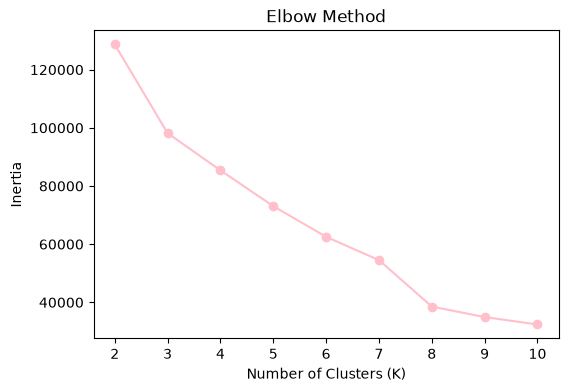

In [91]:
inertia = []

K = range(2, 11)

for k in K:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(features_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, marker='o', color='pink')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

##### With the elbow method we are meant to choose a K value where inertia begins to decrease at a slower rate and flatten, therefore, I chose K=8. Before K=8, although the plot seemed to flatten, there were significant decreases in intertia from K=7 to K=8. After K=8, there were smaller reductions in inertia meaning that adding more clusters didn't have much impact on inertia. Hence, I am choosing 8 as my K value.

In [92]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42
)

df["feature_cluster"] = kmeans.fit_predict(features_scaled)

In [93]:
pca = PCA(n_components=2)

features_pca = pca.fit_transform(features_scaled)

df["PC1"] = features_pca[:,0]
df["PC2"] = features_pca[:,1]

##### I reduced the features to 2 dimensions using PCA, which would make it easier to plot while also retaining all of the important information.

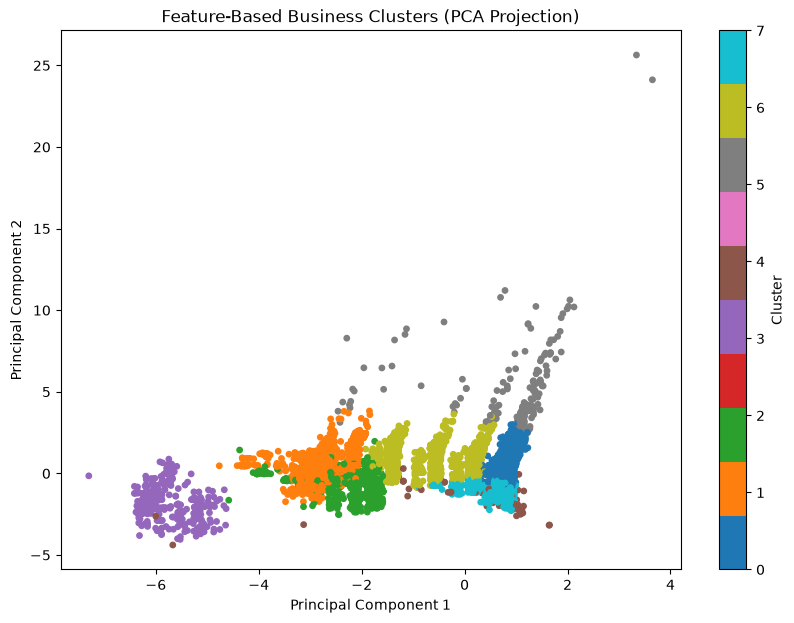

In [94]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["PC1"],
    df["PC2"],
    c=df["feature_cluster"],
    cmap="tab10",
    s=15
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Feature-Based Business Clusters (PCA)")
plt.colorbar(label="Cluster")

plt.show()

In [95]:
cluster_summary = df.groupby("feature_cluster").agg({
    "numberofemployees":"mean",
    "feepaid":"mean",
    "licence_duration":"mean",
    "licencerevisionnumber":"mean",
    "businesstype_clean":lambda x: x.mode()[0]
})

cluster_summary

,numberofemployees,feepaid,licence_duration,licencerevisionnumber,businesstype_clean
feature_cluster,,,,,
0,15.360818,728.645305,391.355171,0.005271,Other
1,8.531425,525.507940,212.366521,0.127567,Other
2,7.492007,221.593250,70.567496,0.162522,Other
3,8.123377,398.984935,144.646104,10.607143,Other
4,1147.567308,327.884615,349.125000,0.240385,Financial Services
5,35.401163,13189.424419,358.813953,0.000000,Long-term Rental
6,10.753035,612.449813,334.129318,0.046452,Other
7,12.684270,283.100880,388.903859,0.014669,Health Care Professionals and Services


### What do the resulting clusters seem to represent? Does this differ from the purely geographic clustering in A2?

#### Result Representation

##### Feature-based clustering grouped together businesses that have similar characteristics such as number of employees, fees paid, duration of their license, amount of times their license has been revised, industry, and which month their license was issued. Each cluster seems to have a defining feature. For instance, cluster 4 seems to have very large businesses with an average employee count above 1000. This makes sense as the primary industry in this cluster is financial services. Cluster 0 seems to be full of more medium-sized businesses with moderate fees and long licence durations and mostly grouped into the "Other" industry category. Cluster 1 consists of smaller businesses with lower fees and slightly shorter licence durations. Cluster 2 consists of businesses with the shortest licence durations and lowest fees and employee count which suggests that this is the group of the newest businesses that have the smallest operations. Cluster 3 has a substantially higher license revision count in comparison to other clusters meaning that they likely get their licenses renewed or fixed a lot. Cluster 5 seems to consist of big businesses as well as they have extremely high licence fees, are primarily long-term rental businesses, and have the second-highest average employee count. Cluster 6 is similar to cluster 0 as they both seem like medium-sized businesses but cluster 6 seems slightly smaller as it has lower average fees, number of employees, and license duration. Lastly, cluster 7 seems to be an industry-specific cluster similar to cluster 4 and 5. Cluster 7 caters to health care professionals and services.

#### Difference from A2 Clustering

##### Yes this does differ from the geographic clustering in A2. In A2, businesses were grouped together and formed clusters based on neighbourhoods and their business density regardless of their characteristics. In contrast, A3 groups together businesses that share similar features and characteristics regardless of their geographic location within Vancouver. This means that businesses from different areas, even opposite sides of the city, can belong to the same feature-based cluster if they have a similar employee count, amount of fees paid, license duration, license revision number, industry, and license issued month. Whereas A2 clustering caters toward location and geography, A3 clustering caters towards individual business features.